In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Đường dẫn đến thư mục chứa file nhãn và ảnh
label_path = "/content/drive/MyDrive/DATN0505/dataset/labels"
image_path = "/content/drive/MyDrive/DATN0505/dataset/images"
image_exts = [".jpg", ".png", ".jpeg"]

# Duyệt qua tất cả các file nhãn
for label_file in os.listdir(label_path):
    if label_file.endswith(".txt"):  # Chỉ xử lý file .txt
        file_path = os.path.join(label_path, label_file)

        # Đọc nội dung file nhãn
        with open(file_path, "r") as f:
            lines = f.readlines()

        # Xóa các dòng chứa nhãn "3"
        new_lines = [line for line in lines if not line.startswith("3 ") and not line.startswith("3\n")]

        if not new_lines:  # Nếu file nhãn trở thành rỗng sau khi xóa nhãn 3
            os.remove(file_path)  # Xóa file nhãn
            print(f"Deleted empty label file: {label_file}")
            # Xóa ảnh tương ứng
            image_name = os.path.splitext(label_file)[0]  # Tên ảnh trùng với tên file nhãn
            for ext in image_exts:
                image_file = os.path.join(image_path, image_name + ext)
                if os.path.exists(image_file):
                    os.remove(image_file)
                    print(f"Deleted image: {image_name + ext}")
        else:
            # Nếu file vẫn còn dòng khác sau khi xóa nhãn 3, cập nhật file
            with open(file_path, "w") as f:
                f.writelines(new_lines)
            print(f"Updated label file: {label_file}")


Updated label file: image1_841_png.rf.ad7f0f67fe2d512d2f0952f64be1f519.txt
Updated label file: image1_548_png.rf.7c556067226aad552c3be1f62f3a53f2.txt
Updated label file: image2_414_png.rf.81fbb02899aff6b76311d6374d5f1eb4.txt
Updated label file: image1_886_png.rf.11851943fee7ef41dd95775fa15565a7.txt
Updated label file: image1_748_png.rf.85a74924f080fec8954c60d59bdb6d8a.txt
Updated label file: image1_6064_png.rf.cb5f5648c1994cfdac70b615c034a648.txt
Updated label file: image1_689_png.rf.3211279aff7a938d8875e214e8d0f05a.txt
Updated label file: image1_6589_png.rf.920ddfcc9128af0d4ebdb4ecf65716f4.txt
Updated label file: image1_80_png.rf.fa4d3bf76a2d2a2ac0645263d7566082.txt
Updated label file: image1_816_png.rf.434e1a09239ad165d5fccdb114031e5d.txt
Updated label file: image1_7817_png.rf.bc14d80bef93d856ea1e7de31fe77c85.txt
Updated label file: image2_1196_png.rf.af3a6f8258308970791581ac6a67b53f.txt
Updated label file: image1_7121_png.rf.2f9d5da98a0bd1bc14564ddec89a94ce.txt
Updated label file: i

In [ ]:
import os

folder_path = '/content/drive/MyDrive/DATN0505/dataset/labels'  # 👉 chỉnh lại đường dẫn thư mục của bạn

for filename in os.listdir(folder_path):
    if filename.endswith('.txt'):
        file_path = os.path.join(folder_path, filename)

        with open(file_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            label = int(parts[0])
            if label in {3, 4, 5, 6}:
                label -= 1
            parts[0] = str(label)
            new_lines.append(' '.join(parts))

        with open(file_path, 'w') as f:
            for line in new_lines:
                f.write(line + '\n')

print('✅ Đã xử lý xong tất cả các file .txt!')


✅ Đã xử lý xong tất cả các file .txt!


In [ ]:
import os
import shutil
import random

# Đường dẫn đến thư mục chứa ảnh và nhãn
dataset_path = "/content/drive/MyDrive/DATN0505/dataset"
image_folder = os.path.join(dataset_path, "images")
label_folder = os.path.join(dataset_path, "labels")
dataset = "/content/drive/MyDrive/DATN0505"
# Đường dẫn đến thư mục lưu trữ tập Train, Test, Valid
train_path = os.path.join(dataset, "train")
valid_path = os.path.join(dataset, "valid")
test_path = os.path.join(dataset, "test")

# Tạo thư mục đầu ra nếu chưa có
for path in [train_path, valid_path, test_path]:
    os.makedirs(os.path.join(path, "images"), exist_ok=True)
    os.makedirs(os.path.join(path, "labels"), exist_ok=True)

# Lấy danh sách tất cả các file ảnh
image_exts = [".jpg", ".png", ".jpeg"]
image_files = [f for f in os.listdir(image_folder) if any(f.endswith(ext) for ext in image_exts)]

# Trộn ngẫu nhiên dữ liệu
random.seed(42)  # Để đảm bảo kết quả nhất quán
random.shuffle(image_files)

# Xác định tỷ lệ
train_ratio = 0.8
valid_ratio = 0.1
test_ratio = 0.1

# Chia dữ liệu theo tỷ lệ
total_images = len(image_files)
train_split = int(total_images * train_ratio)
valid_split = int(total_images * (train_ratio + valid_ratio))

train_files = image_files[:train_split]
valid_files = image_files[train_split:valid_split]
test_files = image_files[valid_split:]

# Hàm di chuyển file ảnh & nhãn vào thư mục mới
def move_files(file_list, dest_folder):
    for file in file_list:
        # Di chuyển ảnh
        src_image = os.path.join(image_folder, file)
        dst_image = os.path.join(dest_folder, "images", file)
        if os.path.exists(src_image):
            shutil.copy(src_image, dst_image)

        # Di chuyển nhãn (cùng tên với ảnh, nhưng có đuôi .txt)
        label_file = os.path.splitext(file)[0] + ".txt"
        src_label = os.path.join(label_folder, label_file)
        dst_label = os.path.join(dest_folder, "labels", label_file)
        if os.path.exists(src_label):
            shutil.copy(src_label, dst_label)

# Di chuyển file vào thư mục tương ứng
move_files(train_files, train_path)
move_files(valid_files, valid_path)
move_files(test_files, test_path)

print(f"Tổng số ảnh: {total_images}")
print(f"Tập Train: {len(train_files)} ảnh")
print(f"Tập Valid: {len(valid_files)} ảnh")
print(f"Tập Test: {len(test_files)} ảnh")

Tổng số ảnh: 2060
Tập Train: 1648 ảnh
Tập Valid: 206 ảnh
Tập Test: 206 ảnh


In [ ]:
import os
from collections import defaultdict

# Đường dẫn thư mục chứa file nhãn
label_path = "/content/drive/MyDrive/DATN0505/train/labels"

# Dictionary để lưu số lần xuất hiện của mỗi nhãn
label_count = defaultdict(int)

# Duyệt qua tất cả các file nhãn
for label_file in os.listdir(label_path):
    if label_file.endswith(".txt"):  # Chỉ xử lý file .txt
        file_path = os.path.join(label_path, label_file)

        with open(file_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()  # Tách các phần tử theo khoảng trắng
                if parts:  # Kiểm tra xem dòng có dữ liệu không
                    label = parts[0]  # Nhãn thường là phần tử đầu tiên
                    label_count[label] += 1  # Tăng số lượng tệp chứa nhãn này

# In kết quả
for label, count in sorted(label_count.items()):
    print(f"Nhãn {label}: {count} tệp")

Nhãn 0: 385 tệp
Nhãn 1: 606 tệp
Nhãn 2: 373 tệp
Nhãn 3: 362 tệp
Nhãn 4: 397 tệp
Nhãn 5: 262 tệp


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
import os
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:

model = YOLO('yolov8s.pt')
# Training the model
model.train(data = '/content/drive/MyDrive/DATN0505/data.yaml',
            epochs = 100,
            imgsz = 640,
            seed = 42

)

100%|██████████| 21.5M/21.5M [00:00<00:00, 132MB/s]


Ultralytics 8.3.127 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DATN0505/data.yaml, degrees=0.0, deterministic=True, device=cuda:0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=

100%|██████████| 755k/755k [00:00<00:00, 79.0MB/s]

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

  8                  -1  1   1838080  ultralytics.nn.modules.block.C2f             [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    591360  ultralytics.nn.modules.block.C2f             [768, 256, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 16                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128,

...

                   all        206        227      0.905      0.777      0.842      0.575



100 epochs completed in 1.132 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 22.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.127 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:05<00:00,  1.36it/s]


                   all        206        227      0.905      0.777      0.842      0.575
        elbow positive         36         39      0.944      0.897      0.895      0.652
      fingers positive         53         58      0.911      0.621      0.772      0.525
      forearm fracture         34         39      0.931      0.795      0.885      0.516
               humerus         38         39       0.93      0.872      0.924      0.708
     shoulder fracture         34         38      0.941      0.837      0.938      0.661
        wrist positive         11         14      0.773      0.643      0.636      0.389
Speed: 0.2ms preprocess, 4.7ms inference, 0.0ms loss, 6.5ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ee0a7b86a90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Evaluating the model on the test dataset
metrics = model.val(conf = 0.25, split = 'test')

Ultralytics 8.3.127 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 5.6±6.0 MB/s, size: 12.0 KB)


val: Scanning /content/drive/MyDrive/DATN0505/test/labels... 206 images, 0 backgrounds, 0 corrupt: 100%|██████████| 206/206 [00:01<00:00, 112.58it/s]

val: New cache created: /content/drive/MyDrive/DATN0505/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:05<00:00,  2.42it/s]


                   all        206        243       0.93      0.847      0.915      0.667
        elbow positive         33         40      0.962      0.825      0.907      0.658
      fingers positive         45         57      0.852      0.806      0.872      0.621
      forearm fracture         37         39      0.946      0.897      0.945      0.684
               humerus         27         30      0.963      0.867      0.931       0.73
     shoulder fracture         35         40      0.886      0.825      0.908      0.687
        wrist positive         29         37       0.97      0.865      0.927      0.621
Speed: 1.7ms preprocess, 12.3ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/val


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import random
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

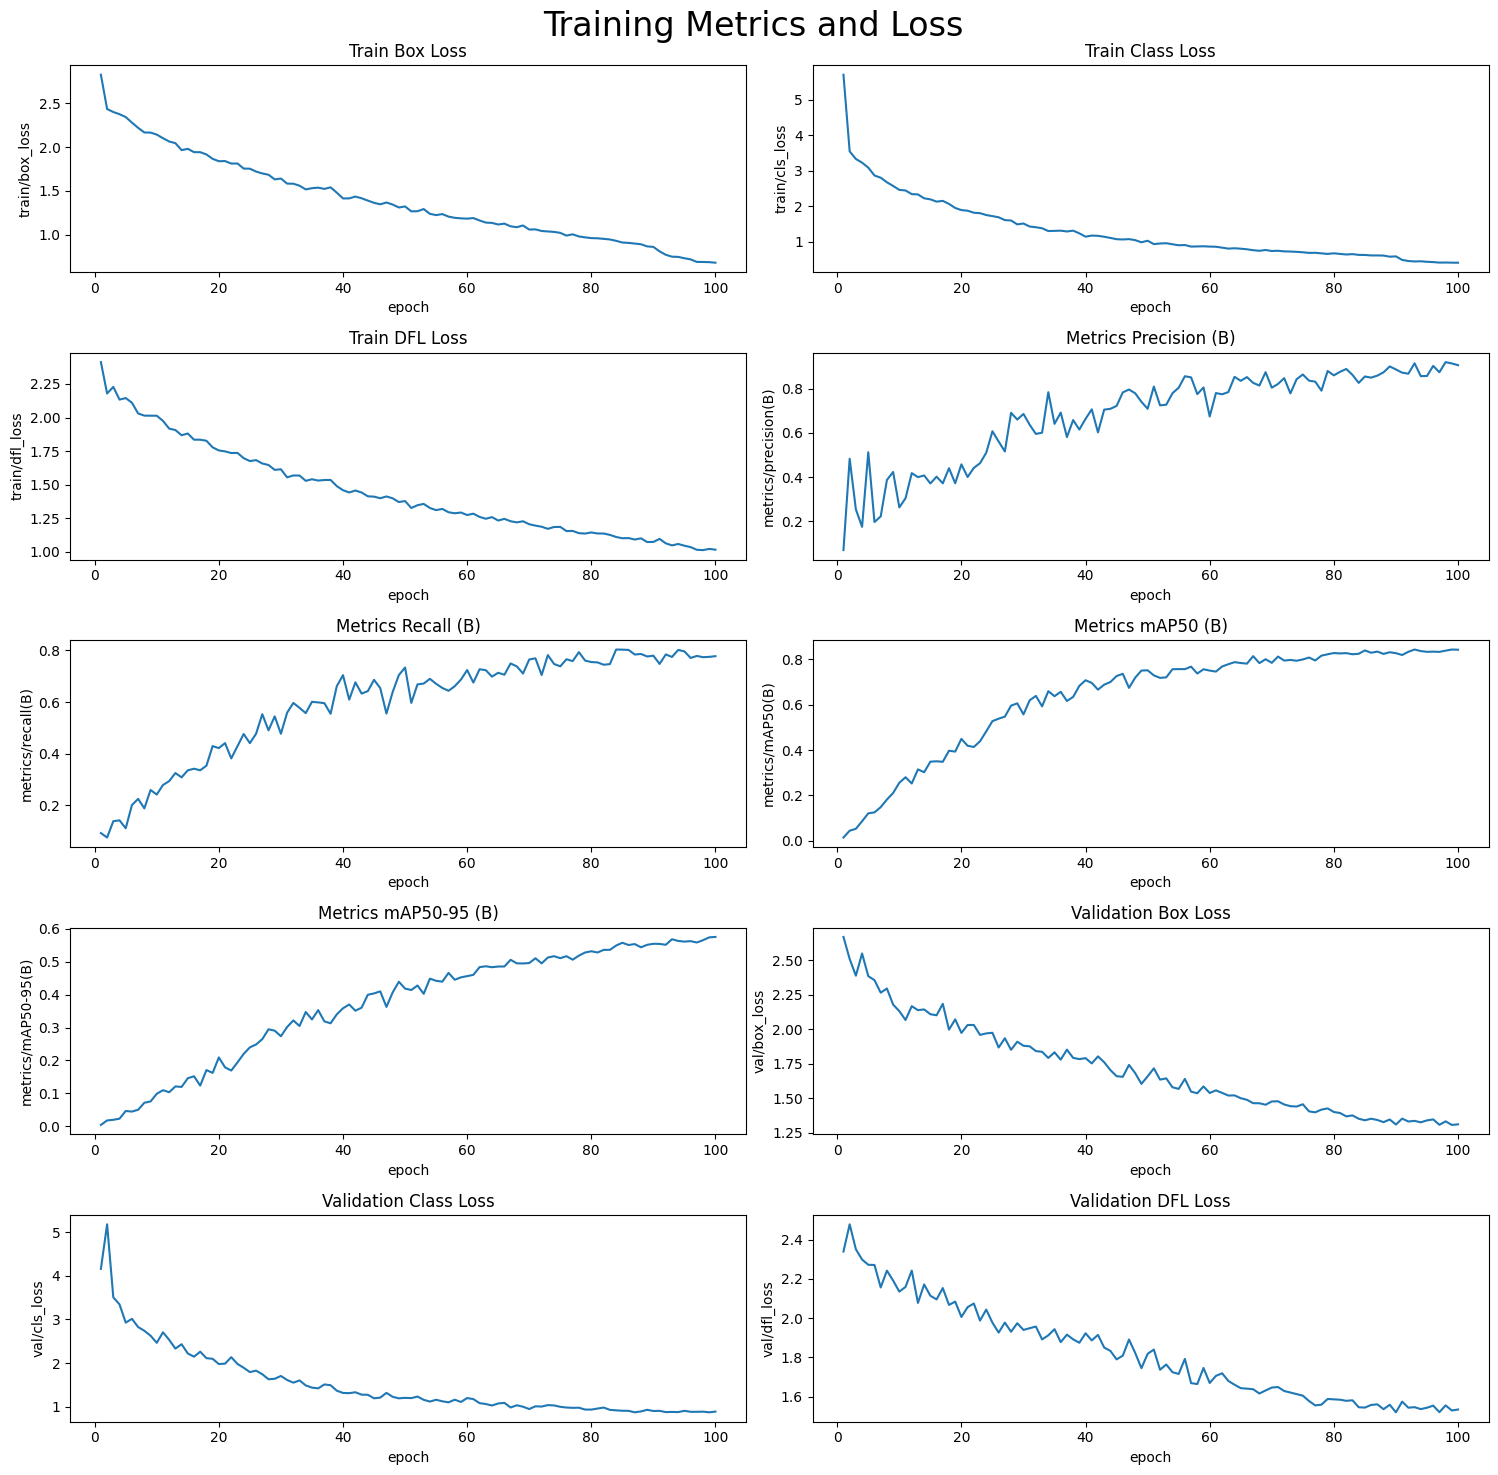

In [ ]:
df = pd.read_csv('/content/runs/detect/train/results.csv')
df.columns = df.columns.str.strip()

# create subplots using seaborn
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

# plot the columns using seaborn
sns.lineplot(x='epoch', y='train/box_loss', data=df, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=df, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=df, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=df, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=df, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=df, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=df, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=df, ax=axs[4,1])

# set titles and axis labels for each subplot
axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train DFL Loss')
axs[1,1].set(title='Metrics Precision (B)')
axs[2,0].set(title='Metrics Recall (B)')
axs[2,1].set(title='Metrics mAP50 (B)')
axs[3,0].set(title='Metrics mAP50-95 (B)')
axs[3,1].set(title='Validation Box Loss')
axs[4,0].set(title='Validation Class Loss')
axs[4,1].set(title='Validation DFL Loss')

# add suptitle and subheader
plt.suptitle('Training Metrics and Loss', fontsize=24)

# adjust top margin to make space for suptitle
plt.subplots_adjust(top=0.8)

# adjust spacing between subplots
plt.tight_layout()

plt.show()

In [ ]:
test_images = '/content/drive/MyDrive/DATN0505/test/images'

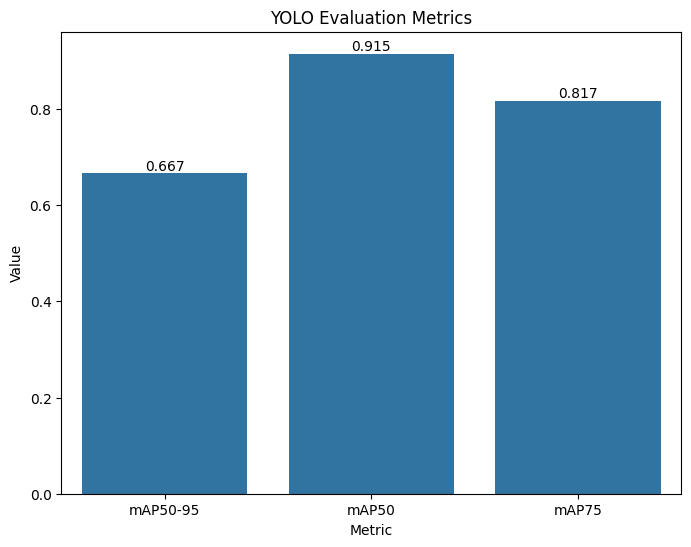

In [ ]:
%matplotlib inline
# Create the barplot
ax = sns.barplot(x=['mAP50-95', 'mAP50', 'mAP75'], y=[metrics.box.map, metrics.box.map50, metrics.box.map75])

# Set the title and axis labels
ax.set_title('YOLO Evaluation Metrics')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')

# Set the figure size
fig = plt.gcf()
fig.set_size_inches(8, 6)

# Add the values on top of the bars
for p in ax.patches:
    ax.annotate('{:.3f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

# Show the plot
plt.show()

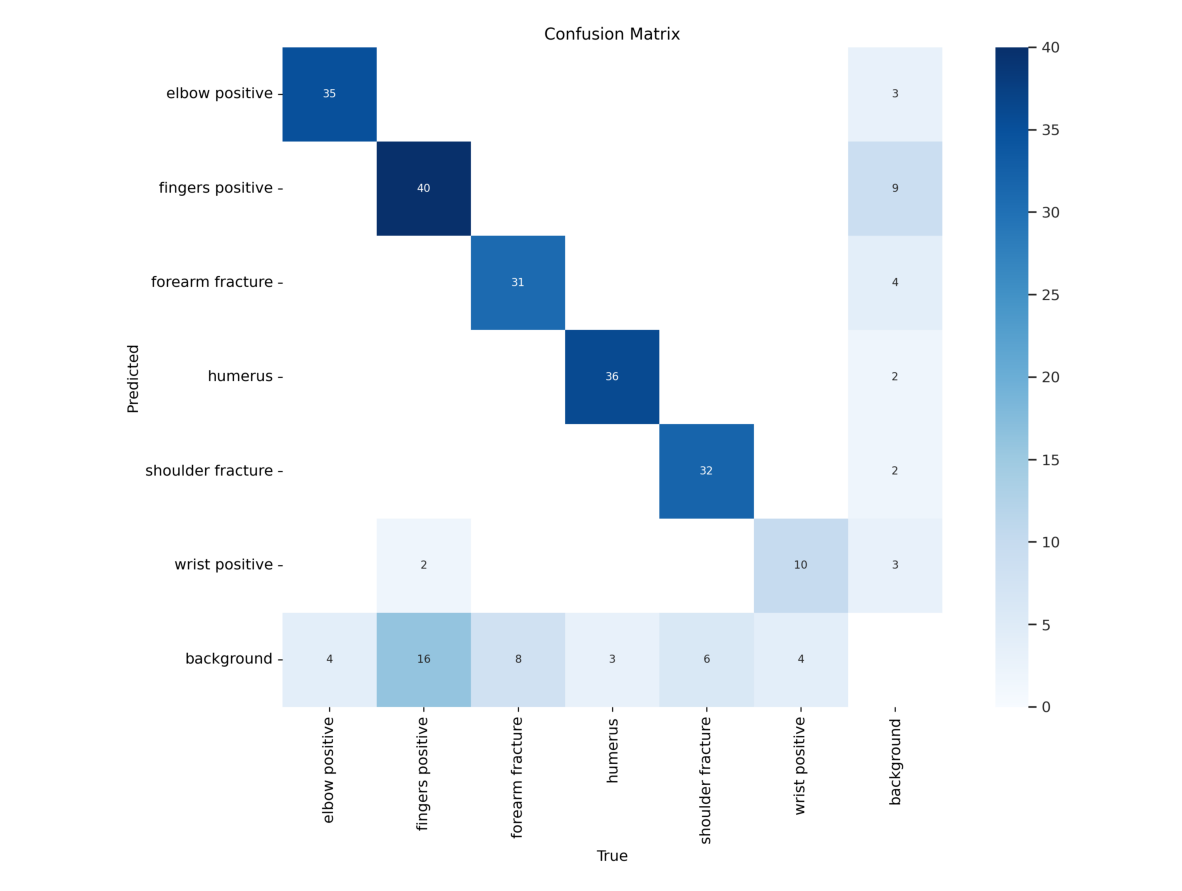

In [ ]:
%matplotlib inline
# Reading the confusion matrix image file
img = mpimg.imread('/content/runs/detect/train/confusion_matrix.png')

# Plotting the confusion matrix image
fig, ax = plt.subplots(figsize = (15, 15))

ax.imshow(img)
ax.axis('off');

In [ ]:
def ship_detect(img_path):

    # Read the image
    img = cv2.imread(img_path)

    # Pass the image through the detection model and get the result
    detect_result = model(img)

    # Plot the detections
    detect_img = detect_result[0].plot()

    # Convert the image to RGB format
    detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)

    return detect_img


0: 640x352 1 fingers positive, 44.0ms
Speed: 1.9ms preprocess, 44.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 352)

0: 640x544 1 humerus, 43.8ms
Speed: 4.0ms preprocess, 43.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 544)

0: 640x256 1 humerus, 43.2ms
Speed: 2.4ms preprocess, 43.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 256)

0: 640x512 2 fingers positives, 39.9ms
Speed: 3.0ms preprocess, 39.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)

0: 640x512 1 fingers positive, 12.0ms
Speed: 3.2ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)

0: 640x512 1 humerus, 12.0ms
Speed: 3.2ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)

0: 512x640 1 shoulder fracture, 38.6ms
Speed: 3.0ms preprocess, 38.6ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)

0: 640x256 1 wrist positive, 9.4ms
Speed: 2.0ms preprocess, 9.4ms infere

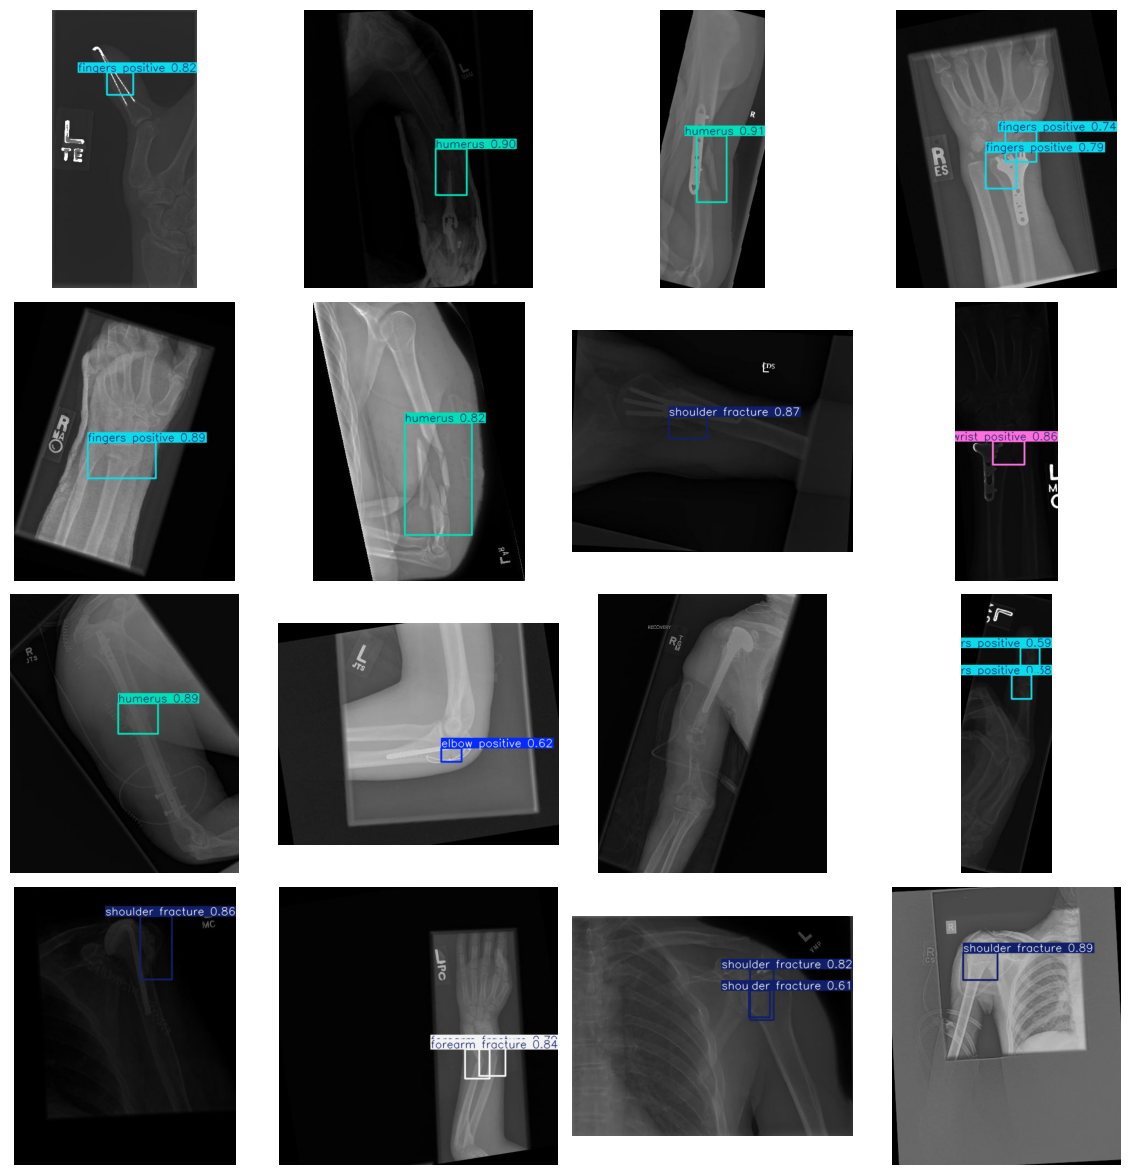

In [ ]:
import random

# Define the directory where the custom images are stored
custom_image_dir = test_images

# Get the list of image files in the directory
image_files = os.listdir(custom_image_dir)

# Select 16 random images from the list
selected_images = random.sample(image_files, 16)

# Create a figure with subplots for each image
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 15))

# Iterate over the selected images and plot each one
for i, img_file in enumerate(selected_images):

    # Compute the row and column index of the current subplot
    row_idx = i // 4
    col_idx = i % 4

    # Load the current image and run object detection
    img_path = os.path.join(custom_image_dir, img_file)
    detect_img = ship_detect(img_path)

    # Plot the current image on the appropriate subplot
    axes[row_idx, col_idx].imshow(detect_img)
    axes[row_idx, col_idx].axis('off')

# Adjust the spacing between the subplots
plt.subplots_adjust(wspace=0.05, hspace=0.05)